In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
import pandas as pd

In [2]:
DATA_DIR = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\BOXED")
ERA5_SST_PATH = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\sst.nc")

# Small region for quick check
REGION = {
    "lat_min": 45,
    "lat_max": 50,
    "lon_min": -50,
    "lon_max": -45,
}

FILE_RE = re.compile(r"ORAS5_(\d{4})_(\d{2})_(.+?)_boxed\.nc$")

In [3]:
sst_files = sorted(DATA_DIR.glob("ORAS5_*_*_sst_boxed.nc"))

print(f"Found {len(sst_files)} SST files")
print(sst_files[:5])

Found 819 SST files
[WindowsPath('C:/Users/itsna/OneDrive/Desktop/MSc_Work/DataSets/ORAS5/BOXED/ORAS5_1958_01_sst_boxed.nc'), WindowsPath('C:/Users/itsna/OneDrive/Desktop/MSc_Work/DataSets/ORAS5/BOXED/ORAS5_1958_02_sst_boxed.nc'), WindowsPath('C:/Users/itsna/OneDrive/Desktop/MSc_Work/DataSets/ORAS5/BOXED/ORAS5_1958_03_sst_boxed.nc'), WindowsPath('C:/Users/itsna/OneDrive/Desktop/MSc_Work/DataSets/ORAS5/BOXED/ORAS5_1958_04_sst_boxed.nc'), WindowsPath('C:/Users/itsna/OneDrive/Desktop/MSc_Work/DataSets/ORAS5/BOXED/ORAS5_1958_05_sst_boxed.nc')]


In [4]:
target_res = 0.25

target_lon = np.arange(REGION["lon_min"], REGION["lon_max"] + target_res, target_res)
target_lat = np.arange(REGION["lat_min"], REGION["lat_max"] + target_res, target_res)

lon2, lat2 = np.meshgrid(target_lon, target_lat)

sst_sum = np.zeros_like(lon2, dtype=float)
sst_count = np.zeros_like(lon2, dtype=float)

In [5]:
for i, f in enumerate(sst_files, start=1):
    print(f"[{i}/{len(sst_files)}] {f.name}")

    with xr.open_dataset(f, engine="netcdf4") as tmp:
        
        sst_var = "sst" if "sst" in tmp.data_vars else list(tmp.data_vars)[0]
        lat_name = "nav_lat" if "nav_lat" in tmp else "latitude"
        lon_name = "nav_lon" if "nav_lon" in tmp else "longitude"

        sst = tmp[sst_var]
        lat = tmp[lat_name]
        lon = tmp[lon_name]

        for dim in ["time_counter", "time", "valid_time"]:
            if dim in sst.dims:
                sst = sst.isel({dim: 0})

        src_lon = lon.values.ravel()
        src_lat = lat.values.ravel()
        src_val = sst.values.ravel()

        if np.nanmean(src_val) > 100:
            src_val = src_val - 273.15

        mask = (
            np.isfinite(src_lon) &
            np.isfinite(src_lat) &
            np.isfinite(src_val) &
            (src_lon >= REGION["lon_min"] - 1) &
            (src_lon <= REGION["lon_max"] + 1) &
            (src_lat >= REGION["lat_min"] - 1) &
            (src_lat <= REGION["lat_max"] + 1)
        )

        points = np.column_stack([src_lon[mask], src_lat[mask]])
        values = src_val[mask]

        sst_interp = griddata(
            points,
            values,
            (lon2, lat2),
            method="linear"
        )

        valid = np.isfinite(sst_interp)
        sst_sum[valid] += sst_interp[valid]
        sst_count[valid] += 1

[1/819] ORAS5_1958_01_sst_boxed.nc
[2/819] ORAS5_1958_02_sst_boxed.nc
[3/819] ORAS5_1958_03_sst_boxed.nc
[4/819] ORAS5_1958_04_sst_boxed.nc
[5/819] ORAS5_1958_05_sst_boxed.nc
[6/819] ORAS5_1958_06_sst_boxed.nc
[7/819] ORAS5_1958_07_sst_boxed.nc
[8/819] ORAS5_1958_08_sst_boxed.nc
[9/819] ORAS5_1958_09_sst_boxed.nc
[10/819] ORAS5_1958_10_sst_boxed.nc
[11/819] ORAS5_1958_11_sst_boxed.nc
[12/819] ORAS5_1958_12_sst_boxed.nc
[13/819] ORAS5_1959_01_sst_boxed.nc
[14/819] ORAS5_1959_02_sst_boxed.nc
[15/819] ORAS5_1959_03_sst_boxed.nc
[16/819] ORAS5_1959_04_sst_boxed.nc
[17/819] ORAS5_1959_05_sst_boxed.nc
[18/819] ORAS5_1959_06_sst_boxed.nc
[19/819] ORAS5_1959_07_sst_boxed.nc
[20/819] ORAS5_1959_08_sst_boxed.nc
[21/819] ORAS5_1959_09_sst_boxed.nc
[22/819] ORAS5_1959_10_sst_boxed.nc
[23/819] ORAS5_1959_11_sst_boxed.nc
[24/819] ORAS5_1959_12_sst_boxed.nc
[25/819] ORAS5_1960_01_sst_boxed.nc
[26/819] ORAS5_1960_02_sst_boxed.nc
[27/819] ORAS5_1960_03_sst_boxed.nc
[28/819] ORAS5_1960_04_sst_boxed.nc
[

In [6]:
era5_ds = xr.open_dataset(ERA5_SST_PATH)

sst = era5_ds["sst"] - 273.15

time_dim = "valid_time"

lat = era5_ds["latitude"]
lon = era5_ds["longitude"]

region_mask = (
    (lat >= REGION["lat_min"]) & (lat <= REGION["lat_max"]) &
    (lon >= REGION["lon_min"]) & (lon <= REGION["lon_max"])
)

sst_region = sst.where(region_mask)

sst_ts = sst_region.mean(dim=("latitude", "longitude"), skipna=True)

df = sst_ts.to_dataframe(name="sst").reset_index()

df["year"] = df[time_dim].dt.year

era5_annual = (
    df.groupby("year", as_index=False)
      .agg(annual_sst_mean=("sst", "mean"))
)

era5_annual.head()

,year,annual_sst_mean
0,1940,6.296146
1,1941,5.566821
2,1942,6.781441
3,1943,6.015147
4,1944,6.522143


In [7]:
sst_mean = np.full_like(sst_sum, np.nan, dtype=float)

valid = sst_count > 0
sst_mean[valid] = sst_sum[valid] / sst_count[valid]

sst_mean_da = xr.DataArray(
    sst_mean,
    dims=("latitude", "longitude"),
    coords={
        "latitude": target_lat,
        "longitude": target_lon,
    },
    name="oras5_sst_mean"
)

sst_mean_da.attrs["units"] = "°C"
sst_mean_da

<xarray.DataArray 'oras5_sst_mean' (latitude: 21, longitude: 21)> Size: 4kB
array([[ 7.20497   ,  6.9332417 ,  6.52509651,  6.12701605,  5.89491052,
         5.99595592,  7.09042538,  9.04511139, 10.19216671, 10.81851086,
        11.18325622, 11.41232988, 11.50240616, 11.48753735, 11.46401031,
        11.48136469, 11.62214187, 11.90888742, 12.34176132, 12.881207  ,
        13.46848694],
       [ 6.95052554,  6.73375878,  6.4300549 ,  6.12477901,  5.84523811,
         5.68095184,  5.94320957,  7.22472906,  8.49460867,  9.35282939,
         9.91448214, 10.26909512, 10.39461295, 10.38563783, 10.42172615,
        10.55991158, 10.84237052, 11.2359856 , 11.7584762 , 12.36865894,
        13.00350749],
       [ 6.79360038,  6.63660162,  6.44244139,  6.24341548,  5.96228051,
         5.64722816,  5.53782094,  5.81683905,  6.54917679,  7.49186182,
         8.34917046,  8.92040659,  9.2188448 ,  9.31016411,  9.44894763,
         9.76424846, 10.18099097, 10.63569563, 11.16100718, 11.74166576,
        12.3593806 ],
       [ 6.70421513,  6.63786319,  6.5311662 ,  6.40778865,  6.20432204,
         5.81972285,  5.41865178,  5.24004883,  5.39599197,  6.05715197,
         7.1926372 ,  7.96636752,  8.33925624,  8.4705274 ,  8.64831319,
         9.020916  ,  9.45939139,  9.8995629 , 10.36944992, 10.90709769,
        11.47486116],
...
       [ 4.13937257,  4.40303484,  4.70517369,  5.00013946,  5.2548258 ,
         5.47689144,  5.69116105,  5.91263063,  6.15783588,  6.43835259,
         6.7687291 ,  7.14861979,  7.49524188,  7.74734798,  7.90217358,
         7.94407661,  7.83776918,  7.61468095,  7.42403618,  7.38482305,
         7.55846258],
       [ 4.10167021,  4.35510626,  4.64924948,  4.93517898,  5.18935775,
         5.41900021,  5.65046815,  5.8986585 ,  6.18343984,  6.51906589,
         6.88242099,  7.26392315,  7.6371356 ,  7.93610761,  8.15030937,
         8.32341452,  8.45505753,  8.49265854,  8.46650426,  8.51818576,
         8.7618033 ],
       [ 4.05829959,  4.31247992,  4.60157835,  4.87552194,  5.12028993,
         5.35289146,  5.59940984,  5.87241328,  6.19306431,  6.59893583,
         7.03668116,  7.42735149,  7.7884163 ,  8.10090549,  8.34279566,
         8.55146201,  8.76093388,  8.9670925 ,  9.15752419,  9.37188228,
         9.65453765],
       [ 4.05545834,  4.31887462,  4.60167118,  4.85217791,  5.07840811,
         5.309803  ,  5.56712249,  5.8542723 ,  6.18107274,  6.60150118,
         7.0996488 ,  7.54198837,  7.90026508,  8.17237957,  8.38152472,
         8.58802316,  8.83685213,  9.12713627,  9.42504069,  9.707851  ,
         9.97598525]])
Coordinates:
  * latitude   (latitude) float64 168B 45.0 45.25 45.5 45.75 ... 49.5 49.75 50.0
  * longitude  (longitude) float64 168B -50.0 -49.75 -49.5 ... -45.25 -45.0
Attributes:
    units:    °C

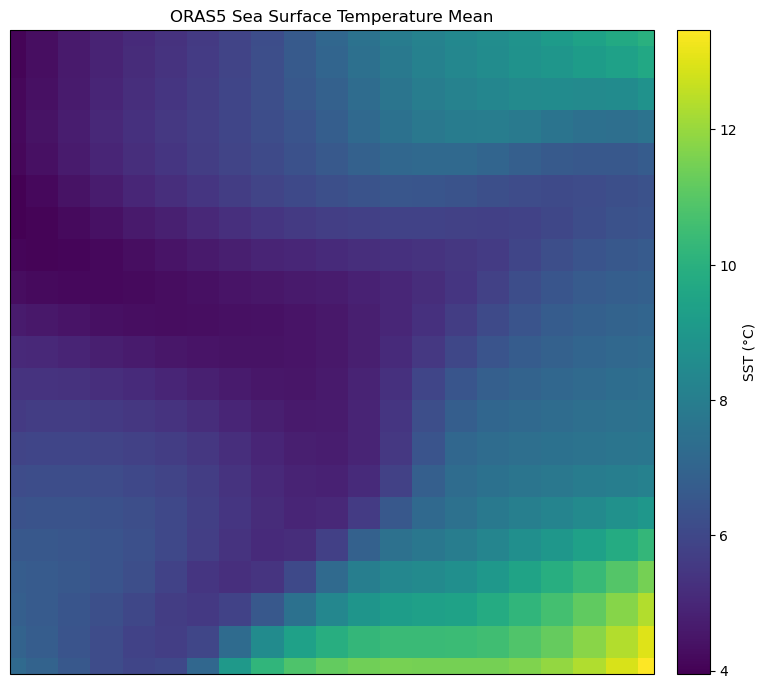

In [8]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent(
    [
        REGION["lon_min"],
        REGION["lon_max"],
        REGION["lat_min"],
        REGION["lat_max"],
    ],
    crs=ccrs.PlateCarree()
)

ax.coastlines(resolution="50m")
ax.add_feature(cfeature.LAND, facecolor="lightgrey", zorder=2)

pm = ax.pcolormesh(
    target_lon,
    target_lat,
    sst_mean_da.values,
    shading="auto",
    transform=ccrs.PlateCarree(),
    cmap="viridis"
)

cbar = plt.colorbar(pm, ax=ax, pad=0.02)
cbar.set_label("SST (°C)")

ax.set_title("ORAS5 Sea Surface Temperature Mean")

plt.tight_layout()
plt.show()

In [9]:
annual_records = []

for i, f in enumerate(sst_files, start=1):
    print(f"[{i}/{len(sst_files)}] {f.name}")

    match = FILE_RE.match(f.name)
    year = int(match.group(1))
    month = int(match.group(2))

    with xr.open_dataset(f, engine="netcdf4") as tmp:

        sst_var = "sst" if "sst" in tmp.data_vars else list(tmp.data_vars)[0]
        lat_name = "nav_lat" if "nav_lat" in tmp else "latitude"
        lon_name = "nav_lon" if "nav_lon" in tmp else "longitude"

        sst = tmp[sst_var]
        lat = tmp[lat_name]
        lon = tmp[lon_name]

        for dim in ["time_counter", "time", "valid_time"]:
            if dim in sst.dims:
                sst = sst.isel({dim: 0})

        region_mask = (
            (lat >= REGION["lat_min"]) &
            (lat <= REGION["lat_max"]) &
            (lon >= REGION["lon_min"]) &
            (lon <= REGION["lon_max"])
        )

        vals = sst.where(region_mask).values

        if np.nanmean(vals) > 100:
            vals = vals - 273.15

        monthly_mean = np.nanmean(vals)

        annual_records.append({
            "year": year,
            "month": month,
            "sst_mean": monthly_mean
        })

[1/819] ORAS5_1958_01_sst_boxed.nc
[2/819] ORAS5_1958_02_sst_boxed.nc
[3/819] ORAS5_1958_03_sst_boxed.nc
[4/819] ORAS5_1958_04_sst_boxed.nc
[5/819] ORAS5_1958_05_sst_boxed.nc
[6/819] ORAS5_1958_06_sst_boxed.nc
[7/819] ORAS5_1958_07_sst_boxed.nc
[8/819] ORAS5_1958_08_sst_boxed.nc
[9/819] ORAS5_1958_09_sst_boxed.nc
[10/819] ORAS5_1958_10_sst_boxed.nc
[11/819] ORAS5_1958_11_sst_boxed.nc
[12/819] ORAS5_1958_12_sst_boxed.nc
[13/819] ORAS5_1959_01_sst_boxed.nc
[14/819] ORAS5_1959_02_sst_boxed.nc
[15/819] ORAS5_1959_03_sst_boxed.nc
[16/819] ORAS5_1959_04_sst_boxed.nc
[17/819] ORAS5_1959_05_sst_boxed.nc
[18/819] ORAS5_1959_06_sst_boxed.nc
[19/819] ORAS5_1959_07_sst_boxed.nc
[20/819] ORAS5_1959_08_sst_boxed.nc
[21/819] ORAS5_1959_09_sst_boxed.nc
[22/819] ORAS5_1959_10_sst_boxed.nc
[23/819] ORAS5_1959_11_sst_boxed.nc
[24/819] ORAS5_1959_12_sst_boxed.nc
[25/819] ORAS5_1960_01_sst_boxed.nc
[26/819] ORAS5_1960_02_sst_boxed.nc
[27/819] ORAS5_1960_03_sst_boxed.nc
[28/819] ORAS5_1960_04_sst_boxed.nc
[

In [10]:
sst_monthly_df = pd.DataFrame(annual_records)

sst_annual_df = (
    sst_monthly_df
    .groupby("year", as_index=False)
    .agg(
        annual_sst_mean=("sst_mean", "mean"),
        n_months=("sst_mean", "count")
    )
)

sst_annual_df.head()

,year,annual_sst_mean,n_months
0,1958,6.523436,12
1,1959,6.043076,12
2,1960,6.833466,12
3,1961,6.981146,12
4,1962,6.586220,12


In [16]:
from scipy.stats import linregress

x = sst_annual_df["year"].values
y = sst_annual_df["annual_sst_mean"].values

trend = linregress(x, y)

sst_annual_df["linear_trend"] = trend.intercept + trend.slope * x

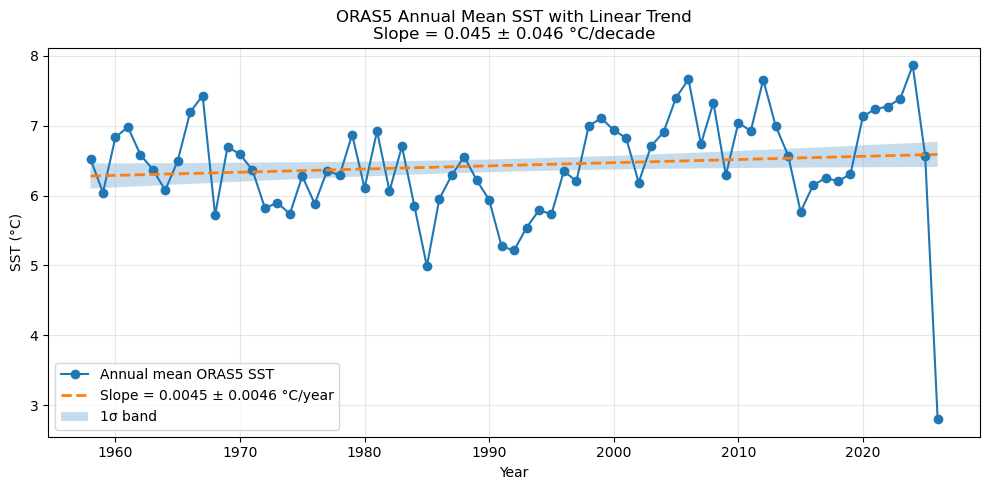

In [12]:
x = sst_annual_df["year"].values.astype(float)
y = sst_annual_df["annual_sst_mean"].values.astype(float)

mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

res = linregress(x, y)

y_fit = res.intercept + res.slope * x

residuals = y - y_fit
npts = len(x)

s = np.sqrt(np.sum(residuals**2) / (npts - 2))

x_mean = np.mean(x)
Sxx = np.sum((x - x_mean)**2)

sigma_y = s * np.sqrt(
    1 / npts + (x - x_mean)**2 / Sxx
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    x,
    y,
    marker="o",
    linewidth=1.5,
    label="Annual mean ORAS5 SST"
)

ax.plot(
    x,
    y_fit,
    linestyle="--",
    linewidth=2,
    label=f"Slope = {res.slope:.4f} ± {res.stderr:.4f} °C/year"
)

ax.fill_between(
    x,
    y_fit - sigma_y,
    y_fit + sigma_y,
    alpha=0.25,
    label="1σ band"
)


ax.set_xlabel("Year")
ax.set_ylabel("SST (°C)")
ax.set_title(
    f"ORAS5 Annual Mean SST with Linear Trend\n"
    f"Slope = {res.slope * 10:.3f} ± {res.stderr * 10:.3f} °C/decade"
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

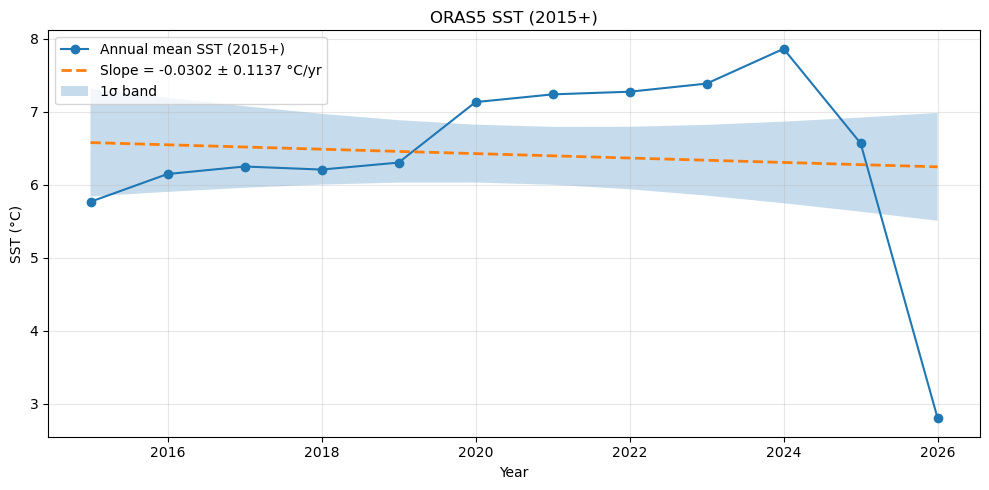

In [19]:
df = sst_annual_df[sst_annual_df["year"] >= 2015].copy()

x = df["year"].values.astype(float)
y = df["annual_sst_mean"].values.astype(float)

mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

res = linregress(x, y)

y_fit = res.intercept + res.slope * x

residuals = y - y_fit
npts = len(x)

s = np.sqrt(np.sum(residuals**2) / (npts - 2))

x_mean = np.mean(x)
Sxx = np.sum((x - x_mean)**2)

sigma_y = s * np.sqrt(1/npts + (x - x_mean)**2 / Sxx)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x, y, marker="o", linewidth=1.5, label="Annual mean SST (2015+)")

ax.plot(
    x,
    y_fit,
    linestyle="--",
    linewidth=2,
    label=f"Slope = {res.slope:.4f} ± {res.stderr:.4f} °C/yr"
)

ax.fill_between(
    x,
    y_fit - sigma_y,
    y_fit + sigma_y,
    alpha=0.25,
    label="1σ band"
)

ax.set_xlabel("Year")
ax.set_ylabel("SST (°C)")
ax.set_title(
    f"ORAS5 SST (2015+)"
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

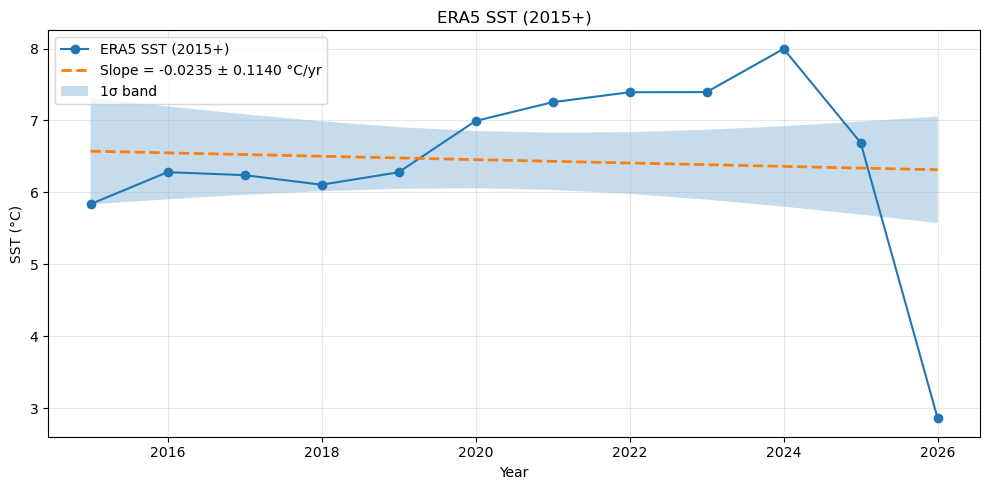

In [18]:
df = era5_annual[era5_annual["year"] >= 2015].copy()

x = df["year"].values.astype(float)
y = df["annual_sst_mean"].values.astype(float)

mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

res = linregress(x, y)

y_fit = res.intercept + res.slope * x

residuals = y - y_fit
npts = len(x)

s = np.sqrt(np.sum(residuals**2) / (npts - 2))

x_mean = np.mean(x)
Sxx = np.sum((x - x_mean)**2)

sigma_y = s * np.sqrt(1/npts + (x - x_mean)**2 / Sxx)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x, y, marker="o", linewidth=1.5, label="ERA5 SST (2015+)")

ax.plot(
    x,
    y_fit,
    linestyle="--",
    linewidth=2,
    label=f"Slope = {res.slope:.4f} ± {res.stderr:.4f} °C/yr"
)

ax.fill_between(
    x,
    y_fit - sigma_y,
    y_fit + sigma_y,
    alpha=0.25,
    label="1σ band"
)

ax.set_xlabel("Year")
ax.set_ylabel("SST (°C)")
ax.set_title(
    f"ERA5 SST (2015+)"
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

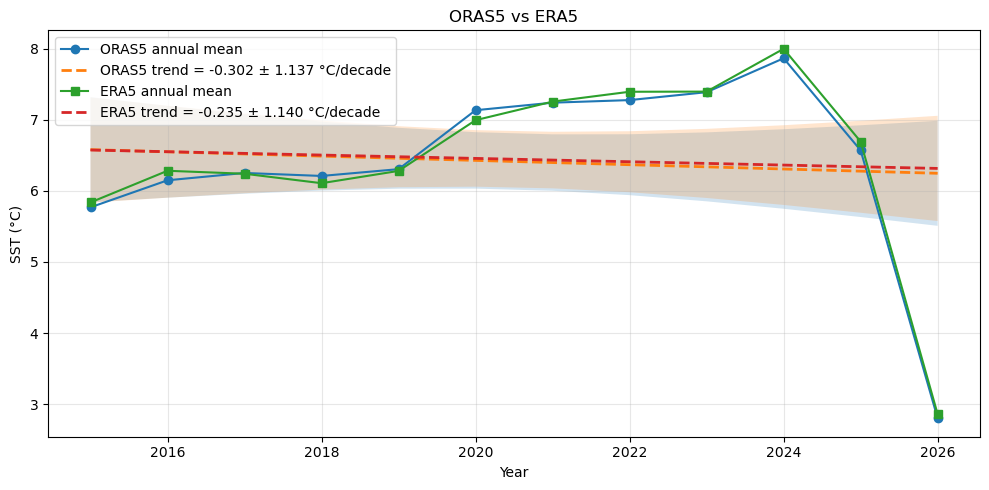

In [20]:
oras5_df = sst_annual_df[sst_annual_df["year"] >= 2015].copy()
era5_df = era5_annual[era5_annual["year"] >= 2015].copy()

fig, ax = plt.subplots(figsize=(10, 5))

# ORAS5
x_o = oras5_df["year"].values.astype(float)
y_o = oras5_df["annual_sst_mean"].values.astype(float)

mask_o = np.isfinite(x_o) & np.isfinite(y_o)
x_o = x_o[mask_o]
y_o = y_o[mask_o]

res_o = linregress(x_o, y_o)
fit_o = res_o.intercept + res_o.slope * x_o

residuals_o = y_o - fit_o
s_o = np.sqrt(np.sum(residuals_o**2) / (len(x_o) - 2))
Sxx_o = np.sum((x_o - np.mean(x_o))**2)
sigma_o = s_o * np.sqrt(1/len(x_o) + (x_o - np.mean(x_o))**2 / Sxx_o)

ax.plot(x_o, y_o, marker="o", linewidth=1.5, label="ORAS5 annual mean")
ax.plot(x_o, fit_o, linestyle="--", linewidth=2,
        label=f"ORAS5 trend = {res_o.slope*10:.3f} ± {res_o.stderr*10:.3f} °C/decade")
ax.fill_between(x_o, fit_o - sigma_o, fit_o + sigma_o, alpha=0.20)


# ERA5
x_e = era5_df["year"].values.astype(float)
y_e = era5_df["annual_sst_mean"].values.astype(float)

mask_e = np.isfinite(x_e) & np.isfinite(y_e)
x_e = x_e[mask_e]
y_e = y_e[mask_e]

res_e = linregress(x_e, y_e)
fit_e = res_e.intercept + res_e.slope * x_e

residuals_e = y_e - fit_e
s_e = np.sqrt(np.sum(residuals_e**2) / (len(x_e) - 2))
Sxx_e = np.sum((x_e - np.mean(x_e))**2)
sigma_e = s_e * np.sqrt(1/len(x_e) + (x_e - np.mean(x_e))**2 / Sxx_e)

ax.plot(x_e, y_e, marker="s", linewidth=1.5, label="ERA5 annual mean")
ax.plot(x_e, fit_e, linestyle="--", linewidth=2,
        label=f"ERA5 trend = {res_e.slope*10:.3f} ± {res_e.stderr*10:.3f} °C/decade")
ax.fill_between(x_e, fit_e - sigma_e, fit_e + sigma_e, alpha=0.20)


ax.set_xlabel("Year")
ax.set_ylabel("SST (°C)")
ax.set_title("ORAS5 vs ERA5")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()